# DTM Kaggle GPU Training Notebook (Large Dataset Safe Mode)

This notebook is designed for Kaggle GPU training with a private Kaggle dataset zip.
It avoids full extraction and streams training tiles directly from the zip file.
This is safer for large datasets (e.g., 20GB zip / 65GB uncompressed).
Outputs are saved to /kaggle/working for download from Kaggle.

In [2]:
# Install dependencies (Kaggle)
!pip install --quiet tqdm numpy matplotlib

In [3]:
# Detect GPU/CPU
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_NAME = "GPU" if torch.cuda.is_available() else "CPU"
print(f"✅ Using {DEVICE_NAME}")

✅ Using GPU


In [7]:
from pathlib import Path
from glob import glob

# Option A (recommended for your current dataset): point to an extracted dataset root
# Expected structure under root: train/, val/, split_manifest.json (optional)
DATASET_ROOT = "/kaggle/input/datasets/jaideepchouhan/point-cloud-data-of-10-indian-villages/Training"  # e.g. /kaggle/input/point-cloud-data-of-10-indian-villages

# Option B: point to a zip if you are using zip-stream mode
DATASET_ZIP_PATH = ""

DATA_SOURCE_MODE = None  # "dir" or "zip"
TRAINING_ROOT = None
DATA_ZIP_PATH = None

def has_train_val(root):
    root = Path(root)
    return (root / "train").exists() and (root / "val").exists()

if DATASET_ROOT:
    root = Path(DATASET_ROOT)
    if not has_train_val(root):
        raise FileNotFoundError(f"DATASET_ROOT missing train/val: {root}")
    DATA_SOURCE_MODE = "dir"
    TRAINING_ROOT = root
elif DATASET_ZIP_PATH:
    zpath = Path(DATASET_ZIP_PATH)
    if not zpath.exists():
        raise FileNotFoundError(f"Dataset zip not found: {zpath}")
    DATA_SOURCE_MODE = "zip"
    DATA_ZIP_PATH = zpath
else:
    dir_candidates = []
    for p in glob('/kaggle/input/**', recursive=True):
        pp = Path(p)
        if pp.is_dir() and has_train_val(pp):
            dir_candidates.append(pp)

    if len(dir_candidates) == 1:
        DATA_SOURCE_MODE = "dir"
        TRAINING_ROOT = dir_candidates[0]
    elif len(dir_candidates) > 1:
        # Prefer roots that include split_manifest.json
        with_manifest = [d for d in dir_candidates if (d / 'split_manifest.json').exists()]
        if len(with_manifest) == 1:
            DATA_SOURCE_MODE = "dir"
            TRAINING_ROOT = with_manifest[0]

    if DATA_SOURCE_MODE is None:
        zip_candidates = sorted(glob('/kaggle/input/**/*.zip', recursive=True))
        if len(zip_candidates) == 1:
            DATA_SOURCE_MODE = "zip"
            DATA_ZIP_PATH = Path(zip_candidates[0])

if DATA_SOURCE_MODE == "dir":
    print(f"✅ Using extracted dataset: {TRAINING_ROOT}")
elif DATA_SOURCE_MODE == "zip":
    zip_size_gb = DATA_ZIP_PATH.stat().st_size / (1024 ** 3)
    print(f"✅ Using dataset zip: {DATA_ZIP_PATH}")
    print(f"   Zip size: {zip_size_gb:.2f} GB")
else:
    raise ValueError(
        "Could not auto-detect dataset source. Set DATASET_ROOT or DATASET_ZIP_PATH explicitly."
    )

✅ Using extracted dataset: /kaggle/input/datasets/jaideepchouhan/point-cloud-data-of-10-indian-villages/Training


In [8]:
# Inspect dataset structure (extracted folder or zip-stream mode)
import json
import zipfile
from pathlib import Path
from collections import Counter

ZIP_ROOT_PREFIX = ""

if DATA_SOURCE_MODE == "dir":
    train_root = Path(TRAINING_ROOT) / 'train'
    val_root = Path(TRAINING_ROOT) / 'val'
    train_tiles = [p for p in train_root.glob('tile_*') if (p / 'labels.npy').exists()]
    val_tiles = [p for p in val_root.glob('tile_*') if (p / 'labels.npy').exists()]

    print("✅ Directory inspection complete")
    print(f"   Dataset root    : {TRAINING_ROOT}")
    print(f"   Train tiles     : {len(train_tiles)}")
    print(f"   Val tiles       : {len(val_tiles)}")

    manifest_path = Path(TRAINING_ROOT) / 'split_manifest.json'
    if manifest_path.exists():
        with open(manifest_path, 'r') as f:
            manifest = json.load(f)
        m_train = len(manifest.get('train', [])) if isinstance(manifest, dict) else None
        m_val = len(manifest.get('val', [])) if isinstance(manifest, dict) else None
        print("   split_manifest  : found")
        if m_train is not None and m_val is not None:
            print(f"   Manifest counts : train={m_train}, val={m_val}")
else:
    with zipfile.ZipFile(DATA_ZIP_PATH, 'r') as z:
        prefixes = Counter()
        train_tiles = set()
        val_tiles = set()

        for info in z.infolist():
            name = info.filename.strip('/')
            parts = name.split('/')
            if 'train' in parts:
                i = parts.index('train')
                prefix = '/'.join(parts[:i])
                prefixes[prefix] += 1
                if i + 1 < len(parts) and parts[i + 1].startswith('tile_'):
                    train_tiles.add(parts[i + 1])
            if 'val' in parts:
                i = parts.index('val')
                if i + 1 < len(parts) and parts[i + 1].startswith('tile_'):
                    val_tiles.add(parts[i + 1])

    ZIP_ROOT_PREFIX = prefixes.most_common(1)[0][0] if prefixes else ""
    print("✅ Zip inspection complete")
    print(f"   ZIP_ROOT_PREFIX : '{ZIP_ROOT_PREFIX}'")
    print(f"   Train tiles     : {len(train_tiles)}")
    print(f"   Val tiles       : {len(val_tiles)}")
    print("ℹ️ Training will stream directly from zip to avoid disk-space issues.")

✅ Directory inspection complete
   Dataset root    : /kaggle/input/datasets/jaideepchouhan/point-cloud-data-of-10-indian-villages/Training
   Train tiles     : 14418
   Val tiles       : 3955
   split_manifest  : found
   Manifest counts : train=16476, val=4120


## Run Order + Execution Plan (Kaggle, memory-safe + resumable + auto-promotion)

1. Install dependencies and detect GPU.
2. Detect dataset source from `/kaggle/input` (prefers extracted `train/val`, falls back to zip).
3. Inspect structure and tile counts (and `split_manifest.json` when available).
4. Configure staged training and resume behavior.
5. Build model + dataset loader.
6. Train with automatic profile promotion when metrics stabilize.
7. Continue from checkpoint in the next Kaggle session.
8. Collect outputs from `/kaggle/working`.

### Why this is safest for 65GB raw data
- Avoids unnecessary extraction when zip mode is used.
- Uses extracted folders directly when Kaggle already unpacked data.
- Starts with small tile caps and promotes automatically by metric stability.
- Checkpoints preserve progress across session limits.

In [24]:
# Kaggle config (auto source mode + resume + automatic profile promotion)
from pathlib import Path
import os

RUN_PROFILE = "full"  # "sanity" | "medium" | "full"
PROFILE_OVERRIDES = {
    "sanity": {"epochs": 12, "max_train_tiles": 200, "max_val_tiles": 40, "batch_size": 2},
    "medium": {"epochs": 18, "max_train_tiles": 800, "max_val_tiles": 160, "batch_size": 5},
    "full": {"epochs": 50, "max_train_tiles": 14418, "max_val_tiles": 3955, "batch_size": 5},
}
PROFILE_ORDER = ["sanity", "medium", "full"]

if RUN_PROFILE not in PROFILE_OVERRIDES:
    raise ValueError(f"Unknown RUN_PROFILE={RUN_PROFILE}")

start_idx = PROFILE_ORDER.index(RUN_PROFILE)
stage_plan = []
for p in PROFILE_ORDER[start_idx:]:
    stage_plan.append({
        "name": p,
        "max_train_tiles": PROFILE_OVERRIDES[p]["max_train_tiles"],
        "max_val_tiles": PROFILE_OVERRIDES[p]["max_val_tiles"],
        "batch_size": PROFILE_OVERRIDES[p]["batch_size"],
    })

cpu_count = os.cpu_count() or 2

KAGGLE_CONFIG = {
    "use_zip_dataset": (DATA_SOURCE_MODE == "zip"),
    "zip_path": str(DATA_ZIP_PATH) if DATA_ZIP_PATH is not None else "",
    "zip_root_prefix": ZIP_ROOT_PREFIX,
    "training_dir": str(TRAINING_ROOT) if TRAINING_ROOT is not None else None,
    "logs_dir": "/kaggle/working/logs",
    "model_save_path": "/kaggle/working/logs/best_model.pth",
    "history_save_path": "/kaggle/working/logs/history.json",
    "curves_save_path": "/kaggle/working/logs/training_curves.png",
    "latest_checkpoint_path": "/kaggle/working/logs/latest_checkpoint.pth",
    "resume_checkpoint_path": "",
    "resume_training": True,
    "epochs": PROFILE_OVERRIDES[RUN_PROFILE]["epochs"],
    "learning_rate": 0.001,
    "early_stop_patience": 12,
    "random_seed": 42,
    "max_points_per_block": 4096,
    "num_workers": 3,
    "prefetch_factor": 2,
    "class_weight_sample_tiles": 200,
    "auto_profile_promotion": True,
    "promotion_window": 2,
    "promotion_min_epochs_in_stage": 2,
    "promotion_min_val_acc": 0.82,
    "promotion_min_f1": 0.72,
    "promotion_max_val_acc_std": 0.02,
    "stage_plan": stage_plan,
    "max_train_tiles": stage_plan[0]["max_train_tiles"],
    "max_val_tiles": stage_plan[0]["max_val_tiles"],
    "batch_size": stage_plan[0]["batch_size"],
    "use_amp": True,
    "val_every": 2,
}

if KAGGLE_CONFIG["use_zip_dataset"]:
    if not Path(KAGGLE_CONFIG["zip_path"]).exists():
        raise FileNotFoundError(f"Zip not found: {KAGGLE_CONFIG['zip_path']}")
else:
    train_root = Path(KAGGLE_CONFIG["training_dir"]) / "train"
    val_root = Path(KAGGLE_CONFIG["training_dir"]) / "val"
    if not train_root.exists() or not val_root.exists():
        raise FileNotFoundError(
            f"Expected train/val under {KAGGLE_CONFIG['training_dir']}"
        )

Path(KAGGLE_CONFIG["logs_dir"]).mkdir(parents=True, exist_ok=True)
print("✅ Kaggle config ready")
print("   Source mode:", "ZIP streaming" if KAGGLE_CONFIG["use_zip_dataset"] else "Extracted folders")
print("   Profile:", RUN_PROFILE)
print("   Initial stage:", KAGGLE_CONFIG["stage_plan"][0]["name"])
print("   Initial Train/Val tiles:", KAGGLE_CONFIG["max_train_tiles"], "/", KAGGLE_CONFIG["max_val_tiles"])
print("   Epochs:", KAGGLE_CONFIG["epochs"])
print("   Batch size:", KAGGLE_CONFIG["batch_size"])
print("   Num workers:", KAGGLE_CONFIG["num_workers"])
print("   Prefetch factor:", KAGGLE_CONFIG["prefetch_factor"])
print("   AMP:", KAGGLE_CONFIG["use_amp"])
print("   Validate every N epochs:", KAGGLE_CONFIG["val_every"])

✅ Kaggle config ready
   Source mode: Extracted folders
   Profile: full
   Initial stage: full
   Initial Train/Val tiles: 14418 / 3955
   Epochs: 50
   Batch size: 5
   Num workers: 3
   Prefetch factor: 2
   AMP: True
   Validate every N epochs: 2


In [25]:
# Model definition (PointNet++)
import torch
import torch.nn as nn
import torch.nn.functional as F

def farthest_point_sample(xyz, n_sample):
    B, N, _ = xyz.shape
    centroids = torch.zeros(B, n_sample, dtype=torch.long, device=xyz.device)
    distance = torch.ones(B, N, device=xyz.device) * 1e10
    farthest = torch.randint(0, N, (B,), device=xyz.device)
    batch_indices = torch.arange(B, device=xyz.device)
    for i in range(n_sample):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, dim=-1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, dim=-1)[1]
    return centroids

def index_points(pts, idx):
    B = pts.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, device=pts.device).view(view_shape).repeat(repeat_shape)
    new_points = pts[batch_indices, idx, :]
    return new_points

class SetAbstraction(nn.Module):
    def __init__(self, n_ctr, radius, n_samp, in_ch, mlp_dims):
        super().__init__()
        self.n_ctr = n_ctr
        self.radius = radius
        self.n_samp = n_samp
        layers = []
        last_ch = in_ch + 3
        for d in mlp_dims:
            layers.append(nn.Conv2d(last_ch, d, 1))
            layers.append(nn.BatchNorm2d(d))
            layers.append(nn.ReLU(inplace=True))
            last_ch = d
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz, points):
        centroids_idx = farthest_point_sample(xyz, self.n_ctr)
        new_xyz = index_points(xyz, centroids_idx)
        dist = torch.cdist(new_xyz, xyz, p=2)
        dist_mask = dist <= self.radius
        dist = torch.where(dist_mask, dist, torch.full_like(dist, 1e10))
        idx = torch.topk(dist, self.n_samp, dim=-1, largest=False)[1]
        grouped_xyz = index_points(xyz, idx)
        grouped_xyz = grouped_xyz - new_xyz.unsqueeze(2)
        if points is not None:
            grouped_points = index_points(points, idx)
            grouped_points = torch.cat([grouped_xyz, grouped_points], dim=-1)
        else:
            grouped_points = grouped_xyz
        grouped_points = grouped_points.permute(0, 3, 2, 1)
        new_points = self.mlp(grouped_points)
        new_points = torch.max(new_points, dim=2)[0]
        new_points = new_points.permute(0, 2, 1)
        return new_xyz, new_points

class FeaturePropagation(nn.Module):
    def __init__(self, in_ch, mlp_dims):
        super().__init__()
        layers = []
        last_ch = in_ch
        for d in mlp_dims:
            layers.append(nn.Conv1d(last_ch, d, 1))
            layers.append(nn.BatchNorm1d(d))
            layers.append(nn.ReLU(inplace=True))
            last_ch = d
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz1, xyz2, points1, points2):
        dist = torch.cdist(xyz1, xyz2, p=2)
        dists, idx = torch.topk(dist, 3, dim=-1, largest=False)
        dists = torch.clamp(dists, min=1e-10)
        weight = 1.0 / dists
        weight = weight / torch.sum(weight, dim=-1, keepdim=True)
        interpolated = torch.sum(index_points(points2, idx) * weight.unsqueeze(-1), dim=2)
        if points1 is not None:
            new_points = torch.cat([points1, interpolated], dim=-1)
        else:
            new_points = interpolated
        new_points = new_points.permute(0, 2, 1)
        new_points = self.mlp(new_points)
        new_points = new_points.permute(0, 2, 1)
        return new_points

class PointNet2GroundSeg(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.sa1 = SetAbstraction(512, 0.5, 32, 0, [32, 32, 64])
        self.sa2 = SetAbstraction(128, 2.0, 64, 64, [64, 64, 128])
        self.sa3 = SetAbstraction(32, 8.0, 128, 128, [128, 128, 256])
        self.fp3 = FeaturePropagation(256 + 128, [256, 256])
        self.fp2 = FeaturePropagation(256 + 64, [256, 128])
        self.fp1 = FeaturePropagation(128, [128, 128, 128])
        self.head = nn.Sequential(
            nn.Conv1d(128, 128, 1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv1d(128, num_classes, 1)
        )

    def forward(self, xyz):
        l0_xyz = xyz
        l0_points = None
        l1_xyz, l1_points = self.sa1(l0_xyz, l0_points)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)
        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)
        l0_points = self.fp1(l0_xyz, l1_xyz, l0_points, l1_points)
        x = l0_points.permute(0, 2, 1)
        x = self.head(x)
        x = x.permute(0, 2, 1)
        return x

In [26]:
# Dataset loader (directory + zip-stream support)
import io
import zipfile
import numpy as np
from pathlib import Path, PurePosixPath
import torch
from torch.utils.data import Dataset

class PointCloudDataset(Dataset):
    """
    Loads point cloud tiles with labels and applies augmentation.
    Supports both extracted folders and streaming from a zip file.
    """
    def __init__(
        self,
        root_dir=None,
        zip_path=None,
        zip_root_prefix="",
        split="train",
        augment=False,
        max_points=4096,
        max_tiles=None,
        seed=42,
    ):
        self.augment = augment
        self.max_points = max_points
        self.seed = seed
        self.split = split
        self.mode = "zip" if zip_path is not None else "dir"
        self._zip = None

        if self.mode == "dir":
            self.root_dir = Path(root_dir)
            # Infer split label from folder name if available, so logs are accurate.
            if self.root_dir.name in {"train", "val"}:
                self.split = self.root_dir.name
            self.tiles = [p.name for p in self.root_dir.glob('tile_*') if (p / 'labels.npy').exists()]
        else:
            self.root_dir = None
            self.zip_path = Path(zip_path)
            self.zip_root_prefix = zip_root_prefix.strip('/')
            self.tiles = self._discover_tiles_in_zip()

        self.tiles = sorted(self.tiles)
        if max_tiles is not None and len(self.tiles) > max_tiles:
            rng = np.random.default_rng(seed)
            pick = rng.choice(len(self.tiles), size=max_tiles, replace=False)
            self.tiles = [self.tiles[i] for i in sorted(pick)]

        src = self.root_dir if self.mode == "dir" else self.zip_path
        print(f"Loaded {len(self.tiles)} tiles from {src} [{self.split}]")

        # Class imbalance quick check on a small sample
        ground_ratios = []
        sample_n = min(50, len(self.tiles))
        for i in range(sample_n):
            labels = self.load_labels(i)
            ratio = float(np.mean(labels))
            ground_ratios.append(ratio)
        if ground_ratios:
            avg_ratio = float(np.mean(ground_ratios))
            if avg_ratio < 0.05 or avg_ratio > 0.95:
                print(f'⚠️ Warning: Ground ratio extreme ({avg_ratio:.2%}).')

    def _discover_tiles_in_zip(self):
        if not self.zip_path.exists():
            raise FileNotFoundError(f"Zip file not found: {self.zip_path}")
        tiles = set()
        with zipfile.ZipFile(self.zip_path, 'r') as zf:
            for info in zf.infolist():
                parts = PurePosixPath(info.filename).parts
                if self.split in parts:
                    i = parts.index(self.split)
                    if i + 1 < len(parts):
                        tile = parts[i + 1]
                        if tile.startswith('tile_'):
                            tiles.add(tile)
        return list(tiles)

    def _zip_member(self, tile_name, filename):
        prefix = f"{self.zip_root_prefix}/" if self.zip_root_prefix else ""
        return f"{prefix}{self.split}/{tile_name}/{filename}"

    def _ensure_zip_open(self):
        if self._zip is None:
            self._zip = zipfile.ZipFile(self.zip_path, 'r')

    def _load_npy_from_zip(self, member):
        self._ensure_zip_open()
        with self._zip.open(member, 'r') as f:
            data = f.read()
        return np.load(io.BytesIO(data))

    def load_labels(self, idx):
        tile = self.tiles[idx]
        if self.mode == "dir":
            return np.load((Path(self.root_dir) / tile / 'labels.npy')).astype(np.int64)
        return self._load_npy_from_zip(self._zip_member(tile, 'labels.npy')).astype(np.int64)

    def load_points_labels(self, idx):
        tile = self.tiles[idx]
        if self.mode == "dir":
            points = np.load((Path(self.root_dir) / tile / 'points.npy')).astype(np.float32)
            labels = np.load((Path(self.root_dir) / tile / 'labels.npy')).astype(np.int64)
            return points, labels
        points = self._load_npy_from_zip(self._zip_member(tile, 'points.npy')).astype(np.float32)
        labels = self._load_npy_from_zip(self._zip_member(tile, 'labels.npy')).astype(np.int64)
        return points, labels

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        points, labels = self.load_points_labels(idx)

        # Subsample or oversample to fixed size
        if points.shape[0] >= self.max_points:
            choice = np.random.choice(points.shape[0], self.max_points, replace=False)
        else:
            choice = np.random.choice(points.shape[0], self.max_points, replace=True)
        points = points[choice]
        labels = labels[choice]

        if self.augment:
            # Random rotation around Z (terrain is rotationally symmetric)
            angle = np.random.uniform(0, 2 * np.pi)
            rot = np.array([
                [np.cos(angle), -np.sin(angle), 0],
                [np.sin(angle), np.cos(angle), 0],
                [0, 0, 1],
            ], dtype=np.float32)
            points = points @ rot.T

            # Small Gaussian jitter to simulate sensor noise
            points += np.random.normal(0, 0.01, size=points.shape).astype(np.float32)

            # Random uniform scaling to simulate altitude variation
            scale = np.random.uniform(0.9, 1.1)
            points *= scale

        return torch.from_numpy(points), torch.from_numpy(labels)

    def __del__(self):
        if getattr(self, '_zip', None) is not None:
            try:
                self._zip.close()
            except Exception:
                pass

  Model parameters: 436,898
✅ Resumed from checkpoint: /kaggle/working/logs/latest_checkpoint.pth
   Starting at epoch 17
   Previous best val acc: 0.9166

▶ Stage: full | train_tiles=14418 val_tiles=3955 batch=5
   AMP=True | num_workers=3 | val_every=2


/tmp/ipykernel_55/2529907016.py:172: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Loaded 14418 tiles from /kaggle/input/datasets/jaideepchouhan/point-cloud-data-of-10-indian-villages/Training/train [train]
Loaded 3955 tiles from /kaggle/input/datasets/jaideepchouhan/point-cloud-data-of-10-indian-villages/Training/val [val]
  Estimated from 200 tiles
  Ground points   : 3,355,727 (16.1%)
  Non-ground pts  : 17,511,547
  Class weights   : non-ground=0.60, ground=3.11


Ep 17 Train:   0%|          | 0/2883 [00:00<?, ?it/s]/tmp/ipykernel_55/2529907016.py:236: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Ep  17/50 [full] | T-loss 0.1904 T-acc 0.9086 | Val skipped (every 2 ep) | 658s


...

Ep  26/50 [full] | T-loss 0.1936 T-acc 0.9082 | V-loss 0.1846 V-acc 0.9072 | P 0.684 R 0.963 F1 0.800 | 801s


Ep  27/50 [full] | T-loss 0.1894 T-acc 0.9097 | Val skipped (every 2 ep) | 639s


Ep  28/50 [full] | T-loss 0.1853 T-acc 0.9117 | V-loss 0.1808 V-acc 0.9101 | P 0.692 R 0.962 F1 0.805 | 799s


Ep  29/50 [full] | T-loss 0.1819 T-acc 0.9138 | Val skipped (every 2 ep) | 636s


Ep  30/50 [full] | T-loss 0.1791 T-acc 0.9146 | V-loss 0.1844 V-acc 0.8973 | P 0.657 R 0.976 F1 0.785 | 818s

  Early stopping at epoch 30 (no improvement for 12 validation checks)


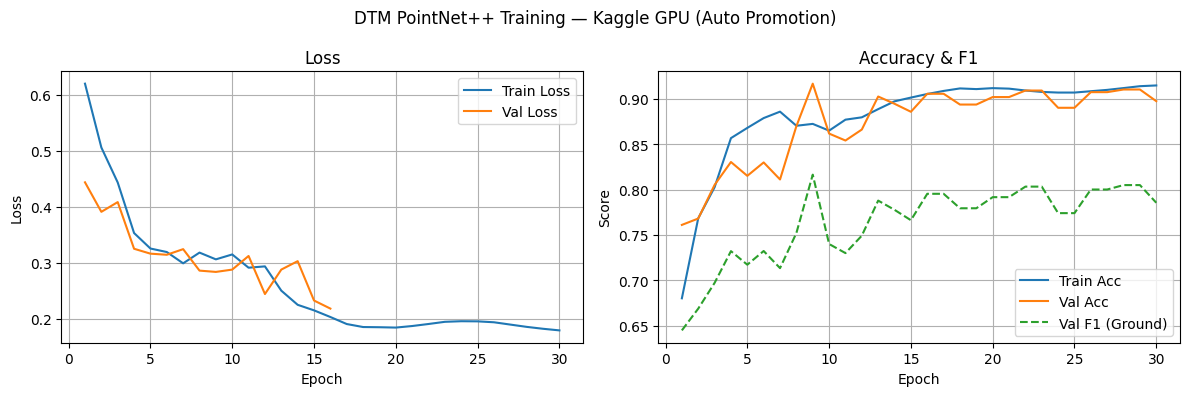


✅ Training complete. Best val acc: 0.9166
   Best model: /kaggle/working/logs/best_model.pth
   Latest ckpt: /kaggle/working/logs/latest_checkpoint.pth


In [27]:
# Training loop (Kaggle GPU, resumable, automatic stage promotion)
import contextlib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from pathlib import Path
import json, time, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def estimate_class_weights(train_ds, sample_tiles, device):
    if len(train_ds) == 0:
        raise ValueError("Training dataset is empty.")

    sample_tiles = min(sample_tiles, len(train_ds))
    rng = np.random.default_rng(42)
    pick = rng.choice(len(train_ds), size=sample_tiles, replace=False)

    n_ground = 0
    n_non_ground = 0
    for i in pick:
        labels = train_ds.load_labels(int(i))
        n_ground += int((labels == 1).sum())
        n_non_ground += int((labels == 0).sum())

    total = n_ground + n_non_ground
    if total == 0:
        raise ValueError("No labels found while estimating class weights.")

    w_ground = total / (2 * n_ground + 1e-9)
    w_non_ground = total / (2 * n_non_ground + 1e-9)
    weights = torch.tensor([w_non_ground, w_ground], dtype=torch.float32).to(device)

    print(f"  Estimated from {sample_tiles} tiles")
    print(f"  Ground points   : {n_ground:,} ({100*n_ground/total:.1f}%)")
    print(f"  Non-ground pts  : {n_non_ground:,}")
    print(f"  Class weights   : non-ground={w_non_ground:.2f}, ground={w_ground:.2f}")
    return weights

def resolve_resume_checkpoint_path(kaggle_config):
    candidate_paths = []
    user_path = kaggle_config.get("resume_checkpoint_path", "").strip()
    latest_path = kaggle_config.get("latest_checkpoint_path", "").strip()
    if user_path:
        candidate_paths.append(Path(user_path))
    if latest_path:
        candidate_paths.append(Path(latest_path))

    for p in candidate_paths:
        if p.exists():
            return p
    return None

def should_promote_stage(history, stage_name, cfg):
    window = int(cfg.get("promotion_window", 2))
    min_epochs = int(cfg.get("promotion_min_epochs_in_stage", 2))
    stage_hist = [h for h in history if h.get("stage") == stage_name]
    if len(stage_hist) < max(window, min_epochs):
        return False

    recent = stage_hist[-window:]
    vals = np.array([h["va"] for h in recent], dtype=np.float64)
    f1s = np.array([h["f1"] for h in recent], dtype=np.float64)

    cond_val = float(np.mean(vals)) >= float(cfg.get("promotion_min_val_acc", 0.86))
    cond_f1 = float(np.mean(f1s)) >= float(cfg.get("promotion_min_f1", 0.80))
    cond_std = float(np.std(vals)) <= float(cfg.get("promotion_max_val_acc_std", 0.02))
    return cond_val and cond_f1 and cond_std

def build_datasets_and_loaders(cfg, device_name):
    if cfg.get("use_zip_dataset", False):
        train_ds = PointCloudDataset(
            zip_path=cfg["zip_path"],
            zip_root_prefix=cfg.get("zip_root_prefix", ""),
            split="train",
            augment=True,
            max_points=cfg["max_points_per_block"],
            max_tiles=cfg.get("max_train_tiles"),
            seed=cfg["random_seed"],
        )
        val_ds = PointCloudDataset(
            zip_path=cfg["zip_path"],
            zip_root_prefix=cfg.get("zip_root_prefix", ""),
            split="val",
            augment=False,
            max_points=cfg["max_points_per_block"],
            max_tiles=cfg.get("max_val_tiles"),
            seed=cfg["random_seed"] + 1,
        )
    else:
        train_ds = PointCloudDataset(
            root_dir=cfg["training_dir"] + "/train",
            augment=True,
            max_points=cfg["max_points_per_block"],
            max_tiles=cfg.get("max_train_tiles"),
            seed=cfg["random_seed"],
        )
        val_ds = PointCloudDataset(
            root_dir=cfg["training_dir"] + "/val",
            augment=False,
            max_points=cfg["max_points_per_block"],
            max_tiles=cfg.get("max_val_tiles"),
            seed=cfg["random_seed"] + 1,
        )

    num_workers = int(cfg.get("num_workers", 2))
    prefetch_factor = int(cfg.get("prefetch_factor", 2))
    pin_memory = device_name == "GPU"

    loader_kwargs = {
        "batch_size": cfg["batch_size"],
        "num_workers": num_workers,
        "pin_memory": pin_memory,
        "persistent_workers": (num_workers > 0),
        "drop_last": True,
    }
    if num_workers > 0:
        loader_kwargs["prefetch_factor"] = prefetch_factor

    train_ld = DataLoader(
        train_ds,
        shuffle=True,
        **loader_kwargs,
    )

    val_loader_kwargs = dict(loader_kwargs)
    val_loader_kwargs["drop_last"] = False
    val_ld = DataLoader(
        val_ds,
        shuffle=False,
        **val_loader_kwargs,
    )
    return train_ds, val_ds, train_ld, val_ld

def apply_stage(cfg, stage_plan, stage_idx):
    s = stage_plan[stage_idx]
    cfg["max_train_tiles"] = int(s["max_train_tiles"])
    cfg["max_val_tiles"] = int(s["max_val_tiles"])
    cfg["batch_size"] = int(s.get("batch_size", cfg.get("batch_size", 2)))
    return s["name"]

def train_on_kaggle(kaggle_config, device, device_name):
    """
    Full training loop optimized for Kaggle GPU/CPU with large datasets.
    Supports resume-from-checkpoint and automatic profile promotion.
    """
    torch.manual_seed(kaggle_config["random_seed"])
    os.makedirs(kaggle_config["logs_dir"], exist_ok=True)

    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True

    model = PointNet2GroundSeg(num_classes=2).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model parameters: {n_params:,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=kaggle_config["learning_rate"],
        weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=kaggle_config["epochs"],
        eta_min=1e-6
    )

    use_amp = bool(kaggle_config.get("use_amp", True) and device_name == "GPU")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    val_every = max(1, int(kaggle_config.get("val_every", 1)))

    latest_checkpoint_path = Path(kaggle_config["latest_checkpoint_path"])
    start_epoch = 1
    best_val_acc = 0.0
    patience_counter = 0
    history = []

    stage_plan = kaggle_config.get("stage_plan", [{
        "name": "single",
        "max_train_tiles": kaggle_config.get("max_train_tiles"),
        "max_val_tiles": kaggle_config.get("max_val_tiles"),
        "batch_size": kaggle_config.get("batch_size", 2),
    }])
    current_stage_idx = 0

    if kaggle_config.get("resume_training", False):
        resume_path = resolve_resume_checkpoint_path(kaggle_config)
        if resume_path is not None:
            ckpt = torch.load(resume_path, map_location=device)
            model.load_state_dict(ckpt["model_state_dict"])
            if "optimizer_state_dict" in ckpt:
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            if "scheduler_state_dict" in ckpt:
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])
            start_epoch = int(ckpt.get("epoch", 0)) + 1
            best_val_acc = float(ckpt.get("best_val_acc", 0.0))
            patience_counter = int(ckpt.get("patience_counter", 0))
            history = ckpt.get("history", [])
            current_stage_idx = int(ckpt.get("current_stage_idx", 0))
            print(f"✅ Resumed from checkpoint: {resume_path}")
            print(f"   Starting at epoch {start_epoch}")
            print(f"   Previous best val acc: {best_val_acc:.4f}")
        else:
            print("ℹ️ Resume enabled but no checkpoint found. Starting fresh.")

    current_stage_idx = max(0, min(current_stage_idx, len(stage_plan) - 1))
    stage_name = apply_stage(kaggle_config, stage_plan, current_stage_idx)
    print(f"\n▶ Stage: {stage_name} | train_tiles={kaggle_config['max_train_tiles']} val_tiles={kaggle_config['max_val_tiles']} batch={kaggle_config['batch_size']}")
    print(f"   AMP={use_amp} | num_workers={kaggle_config.get('num_workers')} | val_every={val_every}")

    train_ds, val_ds, train_ld, val_ld = build_datasets_and_loaders(kaggle_config, device_name)
    weights = estimate_class_weights(
        train_ds,
        sample_tiles=kaggle_config.get("class_weight_sample_tiles", 200),
        device=device,
    )
    criterion = nn.CrossEntropyLoss(weight=weights)

    if start_epoch > kaggle_config["epochs"]:
        print("ℹ️ start_epoch is greater than configured epochs. Nothing to train.")
        return best_val_acc

    for epoch in range(start_epoch, kaggle_config["epochs"] + 1):
        t0 = time.time()

        model.train()
        train_loss = train_ok = train_n = 0
        for pts, labels in tqdm(train_ld, desc=f"Ep {epoch:02d} Train", leave=False):
            pts = pts.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(pts)
                B, N, C = logits.shape
                loss = criterion(logits.reshape(B * N, C), labels.reshape(B * N))

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            preds = logits.argmax(-1)
            train_loss += loss.item() * B
            train_ok += (preds == labels).sum().item()
            train_n += B * N

        run_val = ((epoch % val_every) == 0) or (epoch == kaggle_config["epochs"])
        val_loss = val_ok = val_n = 0
        val_tp = val_fp = val_fn = 0

        if run_val:
            model.eval()
            with torch.no_grad():
                for pts, labels in tqdm(val_ld, desc=f"Ep {epoch:02d} Val", leave=False):
                    pts = pts.to(device, non_blocking=True)
                    labels = labels.to(device, non_blocking=True)
                    with torch.cuda.amp.autocast(enabled=use_amp):
                        logits = model(pts)
                        B, N, C = logits.shape
                        loss = criterion(logits.reshape(B * N, C), labels.reshape(B * N))
                    preds = logits.argmax(-1)
                    val_loss += loss.item() * B
                    val_ok += (preds == labels).sum().item()
                    val_n += B * N
                    val_tp += ((preds == 1) & (labels == 1)).sum().item()
                    val_fp += ((preds == 1) & (labels == 0)).sum().item()
                    val_fn += ((preds == 0) & (labels == 1)).sum().item()

        t_loss = train_loss / max(1, len(train_ds))
        t_acc = train_ok / max(1, train_n)

        if run_val:
            v_loss = val_loss / max(1, len(val_ds))
            v_acc = val_ok / max(1, val_n)
            precision = val_tp / (val_tp + val_fp + 1e-9)
            recall = val_tp / (val_tp + val_fn + 1e-9)
            f1 = 2 * precision * recall / (precision + recall + 1e-9)
        else:
            v_loss = float("nan")
            v_acc = history[-1]["va"] if history else 0.0
            precision = float("nan")
            recall = float("nan")
            f1 = history[-1]["f1"] if history else 0.0

        elapsed = time.time() - t0

        if run_val:
            print(
                f"Ep {epoch:3d}/{kaggle_config['epochs']} [{stage_name}] | "
                f"T-loss {t_loss:.4f} T-acc {t_acc:.4f} | "
                f"V-loss {v_loss:.4f} V-acc {v_acc:.4f} | "
                f"P {precision:.3f} R {recall:.3f} F1 {f1:.3f} | "
                f"{elapsed:.0f}s"
            )
        else:
            print(
                f"Ep {epoch:3d}/{kaggle_config['epochs']} [{stage_name}] | "
                f"T-loss {t_loss:.4f} T-acc {t_acc:.4f} | "
                f"Val skipped (every {val_every} ep) | "
                f"{elapsed:.0f}s"
            )

        scheduler.step()
        history.append({
            "ep": epoch, "stage": stage_name,
            "tl": t_loss, "ta": t_acc,
            "vl": v_loss, "va": v_acc, "f1": f1
        })

        if run_val:
            if v_acc > best_val_acc:
                best_val_acc = v_acc
                patience_counter = 0
                torch.save(model.state_dict(), kaggle_config["model_save_path"])
                print(f"  ** Best model saved (val_acc={best_val_acc:.4f}) **")
            else:
                patience_counter += 1

        promoted = False
        if run_val and kaggle_config.get("auto_profile_promotion", True):
            if current_stage_idx + 1 < len(stage_plan):
                if should_promote_stage(history, stage_name, kaggle_config):
                    current_stage_idx += 1
                    stage_name = apply_stage(kaggle_config, stage_plan, current_stage_idx)
                    print(f"\n🚀 Auto-promoted to stage '{stage_name}'")
                    print(f"   New train/val tiles: {kaggle_config['max_train_tiles']}/{kaggle_config['max_val_tiles']}, batch={kaggle_config['batch_size']}")
                    train_ds, val_ds, train_ld, val_ld = build_datasets_and_loaders(kaggle_config, device_name)
                    weights = estimate_class_weights(
                        train_ds,
                        sample_tiles=kaggle_config.get("class_weight_sample_tiles", 200),
                        device=device,
                    )
                    criterion = nn.CrossEntropyLoss(weight=weights)
                    patience_counter = 0
                    promoted = True

        checkpoint_payload = {
            "epoch": epoch,
            "best_val_acc": best_val_acc,
            "patience_counter": patience_counter,
            "current_stage_idx": current_stage_idx,
            "stage_plan": stage_plan,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": history,
            "kaggle_config": kaggle_config,
        }
        torch.save(checkpoint_payload, latest_checkpoint_path)

        if run_val and (not promoted) and patience_counter >= kaggle_config["early_stop_patience"]:
            print(f"\n  Early stopping at epoch {epoch} "
                  f"(no improvement for {patience_counter} validation checks)")
            break

    with open(kaggle_config["history_save_path"], "w") as f:
        json.dump(history, f, indent=2)

    eps = [h["ep"] for h in history]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(eps, [h["tl"] for h in history], label="Train Loss")
    ax1.plot(eps, [h["vl"] for h in history], label="Val Loss")
    ax1.set(title="Loss", xlabel="Epoch", ylabel="Loss")
    ax1.legend(); ax1.grid(True)
    ax2.plot(eps, [h["ta"] for h in history], label="Train Acc")
    ax2.plot(eps, [h["va"] for h in history], label="Val Acc")
    ax2.plot(eps, [h["f1"] for h in history], label="Val F1 (Ground)", linestyle="--")
    ax2.set(title="Accuracy & F1", xlabel="Epoch", ylabel="Score")
    ax2.legend(); ax2.grid(True)
    plt.suptitle("DTM PointNet++ Training — Kaggle GPU (Auto Promotion)", fontsize=12)
    plt.tight_layout()
    plt.savefig(kaggle_config["curves_save_path"], dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Training complete. Best val acc: {best_val_acc:.4f}")
    print(f"   Best model: {kaggle_config['model_save_path']}")
    print(f"   Latest ckpt: {latest_checkpoint_path}")
    return best_val_acc

# ── TRAIN ──────────────────────────────────────────────────────────────────
best_acc = train_on_kaggle(KAGGLE_CONFIG, device, DEVICE_NAME)

In [ ]:
# Collect outputs from /kaggle/working
from pathlib import Path
import zipfile

outputs = [
    KAGGLE_CONFIG["model_save_path"],
    KAGGLE_CONFIG["latest_checkpoint_path"],
    KAGGLE_CONFIG["history_save_path"],
    KAGGLE_CONFIG["curves_save_path"],
]

missing = [p for p in outputs if not Path(p).exists()]
if missing:
    print("⚠️ Missing outputs:")
    for p in missing:
        print("  -", p)

zip_path = Path('/kaggle/working/outputs.zip')
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in outputs:
        if Path(p).exists():
            z.write(p, arcname=Path(p).name)

print("✅ Outputs ready:")
print("  -", zip_path)
print("  -", KAGGLE_CONFIG["model_save_path"])
print("  -", KAGGLE_CONFIG["latest_checkpoint_path"])
print("  -", KAGGLE_CONFIG["history_save_path"])
print("  -", KAGGLE_CONFIG["curves_save_path"])